In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
df_raw = pd.read_csv('Phishing_URL_ds_5percent_missing.csv')
df_raw.shape

(235795, 56)

Comment: Data has 235795 number of URL instances.

In [153]:
#Checking duplicates
df_raw[df_raw.duplicated()].value_counts()

Series([], Name: count, dtype: int64)

Comments: We have no duplicated observations. There is no problem. 

Standardize Text Columns

In [154]:
for col in df_raw.select_dtypes(include=['object']).columns:
    df_raw[col] = df_raw[col].str.lower().str.strip()

Looking Data

In [155]:
df_raw.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31.0,NaN,24.0,0.0,com,100.0,1.000000,0.522907,...,0.0,0.0,1.0,34.0,20.0,NaN,119.0,0.0,124.0,1.0
1,31372.txt,https://www.uni-mainz.de,23.0,www.uni-mainz.de,16.0,0.0,NaN,100.0,0.666667,0.032650,...,0.0,0.0,1.0,50.0,9.0,8.0,39.0,0.0,217.0,1.0
2,597387.txt,https://www.voicefmradio.co.uk,NaN,www.voicefmradio.co.uk,22.0,0.0,uk,100.0,0.866667,0.028555,...,0.0,0.0,1.0,10.0,2.0,7.0,42.0,2.0,5.0,1.0
3,554095.txt,https://www.sfnmjournal.com,26.0,www.sfnmjournal.com,19.0,0.0,com,100.0,1.000000,0.522907,...,1.0,1.0,NaN,3.0,27.0,15.0,22.0,1.0,31.0,1.0
4,NaN,https://www.rewildingargentina.org,33.0,www.rewildingargentina.org,26.0,0.0,org,100.0,1.000000,0.079963,...,1.0,0.0,1.0,244.0,15.0,34.0,72.0,1.0,85.0,1.0


Comments: Data looks like clean in general.FILENAME seems unnecesarry column for our model. 

In [156]:
#Removing FILENAME column
df_raw = df_raw.drop(df_raw.columns[0], axis=1)

Changing Data Types

In [157]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         223935 non-null  object 
 1   URLLength                   223980 non-null  float64
 2   Domain                      224040 non-null  object 
 3   DomainLength                223911 non-null  float64
 4   IsDomainIP                  223820 non-null  float64
 5   TLD                         223927 non-null  object 
 6   URLSimilarityIndex          224026 non-null  float64
 7   CharContinuationRate        223894 non-null  float64
 8   TLDLegitimateProb           223989 non-null  float64
 9   URLCharProb                 224068 non-null  float64
 10  TLDLength                   223846 non-null  float64
 11  NoOfSubDomain               223980 non-null  float64
 12  HasObfuscation              224050 non-null  float64
 13  NoOfObfuscated

Comment: Column names seems consistent. We create missingness in data, as we can see there are missing values with different numbers in columns. Data types seems consistent with column meanings in general, there is no problem. For columns which have binary values should converted to the int data type. Reason behin this is mathematical rules, for library conformity in scikit-learn, and memory efficiency. Label is also should be converted.

In [158]:
#Convert binary columns data type as Int8(which can store nan values) 

#All features with numeric data types
numeric_df = df_raw.select_dtypes(include=['float64'])

#Features have exactly 2 unique variables
binary_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() == 2]

#Features have more than 2 unique variables are not binary
continuous_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() > 2]

print(f"Binary Feature Number: {len(binary_cols)}")
print(f"Continous Feature Number: {len(continuous_cols)}")
df_raw[binary_cols] = df_raw[binary_cols].astype('Int8')
df_raw.info()

Binary Feature Number: 20
Continous Feature Number: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         223935 non-null  object 
 1   URLLength                   223980 non-null  float64
 2   Domain                      224040 non-null  object 
 3   DomainLength                223911 non-null  float64
 4   IsDomainIP                  223820 non-null  Int8   
 5   TLD                         223927 non-null  object 
 6   URLSimilarityIndex          224026 non-null  float64
 7   CharContinuationRate        223894 non-null  float64
 8   TLDLegitimateProb           223989 non-null  float64
 9   URLCharProb                 224068 non-null  float64
 10  TLDLength                   223846 non-null  float64
 11  NoOfSubDomain               223980 non-null  float64
 12  HasObfuscation   

Cleaning URL Column

In [159]:
#Looking identical URLs
url_counts = df_raw['URL'].value_counts()
print(url_counts)

#Looking same url count number
print(len(url_counts[url_counts > 1]))

URL
https://virginpaperagency.com/cgi/php/errore.php                        2
https://fb-restriction-case-9786a.firebaseapp.com/                      2
https://dev-home-seguridad-itau.pantheonsite.io/                        2
https://s42lkd.webwave.dev/lib/s42lkd/po-ldcuuw59.html                  2
https://marketingtechnologies.es/wp-admin/whidhet/f4db9c3b86f73456f/    2
                                                                       ..
https://topaka.cloud/ob52gtplj/18snwp                                   1
https://www.mlpack.org                                                  1
https://metafb-tvz6efk.web.app/                                         1
http://www.hesselawchambers.com                                         1
https://www.alternativefinland.com                                      1
Name: count, Length: 223548, dtype: int64
387


Comment: We have 387 URL names that seen twice in our dataset. This may cause data leakage. First question that comes to my mind is same url names have same label value?

In [160]:
#Looking url's with corresponding labels
inconsistent = df_raw.groupby('URL')['label'].nunique()
print(inconsistent[inconsistent > 1])

Series([], Name: label, dtype: int64)


Comment: Although the URL names were the same, these URLs were not perceived differently as either phishing or legitimate. To avoid data leakage we remove same URL rows -> 387 rows from our dataset, other 387 with same value still in the dataset to use this informations in our model.

In [161]:
#Remove same url rows
df_raw = df_raw.drop_duplicates(subset=['URL'], keep='first')

#Test whether duplicate url's gone.
url_counts = df_raw['URL'].value_counts()
print(len(url_counts[url_counts > 1]))

0


Cleaning and Feature Engineering for Title Column

In [162]:
counts = df_raw['Title'].value_counts()
print(counts)

Title
0                                                             29496
#name?                                                           19
gov                                                              10
info-update-sucreeblogspot                                       10
65gfgfgfgfg4g4gblogspot?m=1                                       9
                                                              ...  
mechinchem-5cb8aweb                                               1
salutlive                                                         1
recettessimples                                                   1
fb-restriction-case-97be5web                                      1
bulgaria ski - bulgarian ski resorts and holiday bookings.        1
Name: count, Length: 178885, dtype: int64


Comments: 0 values are missing values. We want to research that, rows that has missing value in title column are more phising or just random?

In [163]:
garbage_list = ['0', 0, '#name?', 'nan', 'Null', '']
df_raw['Title'] = df_raw['Title'].replace(garbage_list, np.nan)

#Research Question
print(df_raw[df_raw['Title'].isna()]['label'].value_counts(normalize=True))

label
0    0.839855
1    0.160145
Name: proportion, dtype: Float64


Comment: Yes! There seems a pattern. 84% of those without a title are phishing. For feature engineering and solve high cardinality problem, and for use this title column effiecently we convert this column to is_title_empty column. This can explains the phising mechanism.

Comment: With only is_title_empty in model, models accuarcy is 70%. This says that our new column says something about phisigness. Distintive feature.

Solving Missing Data

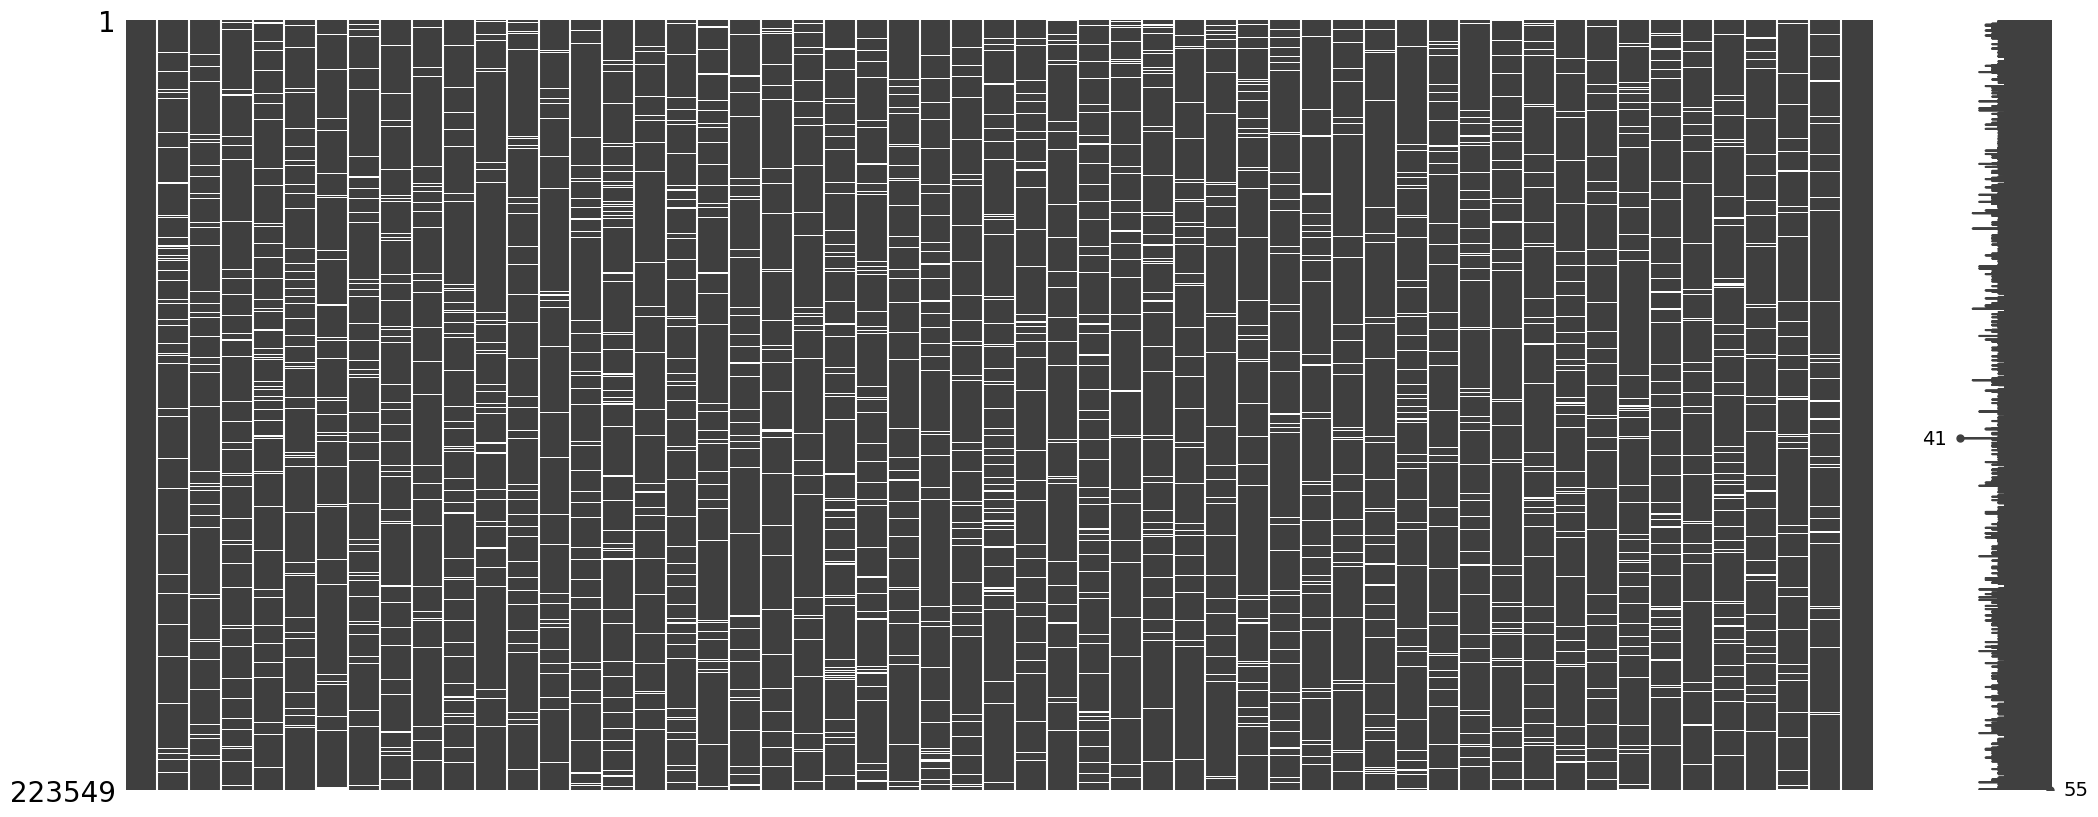

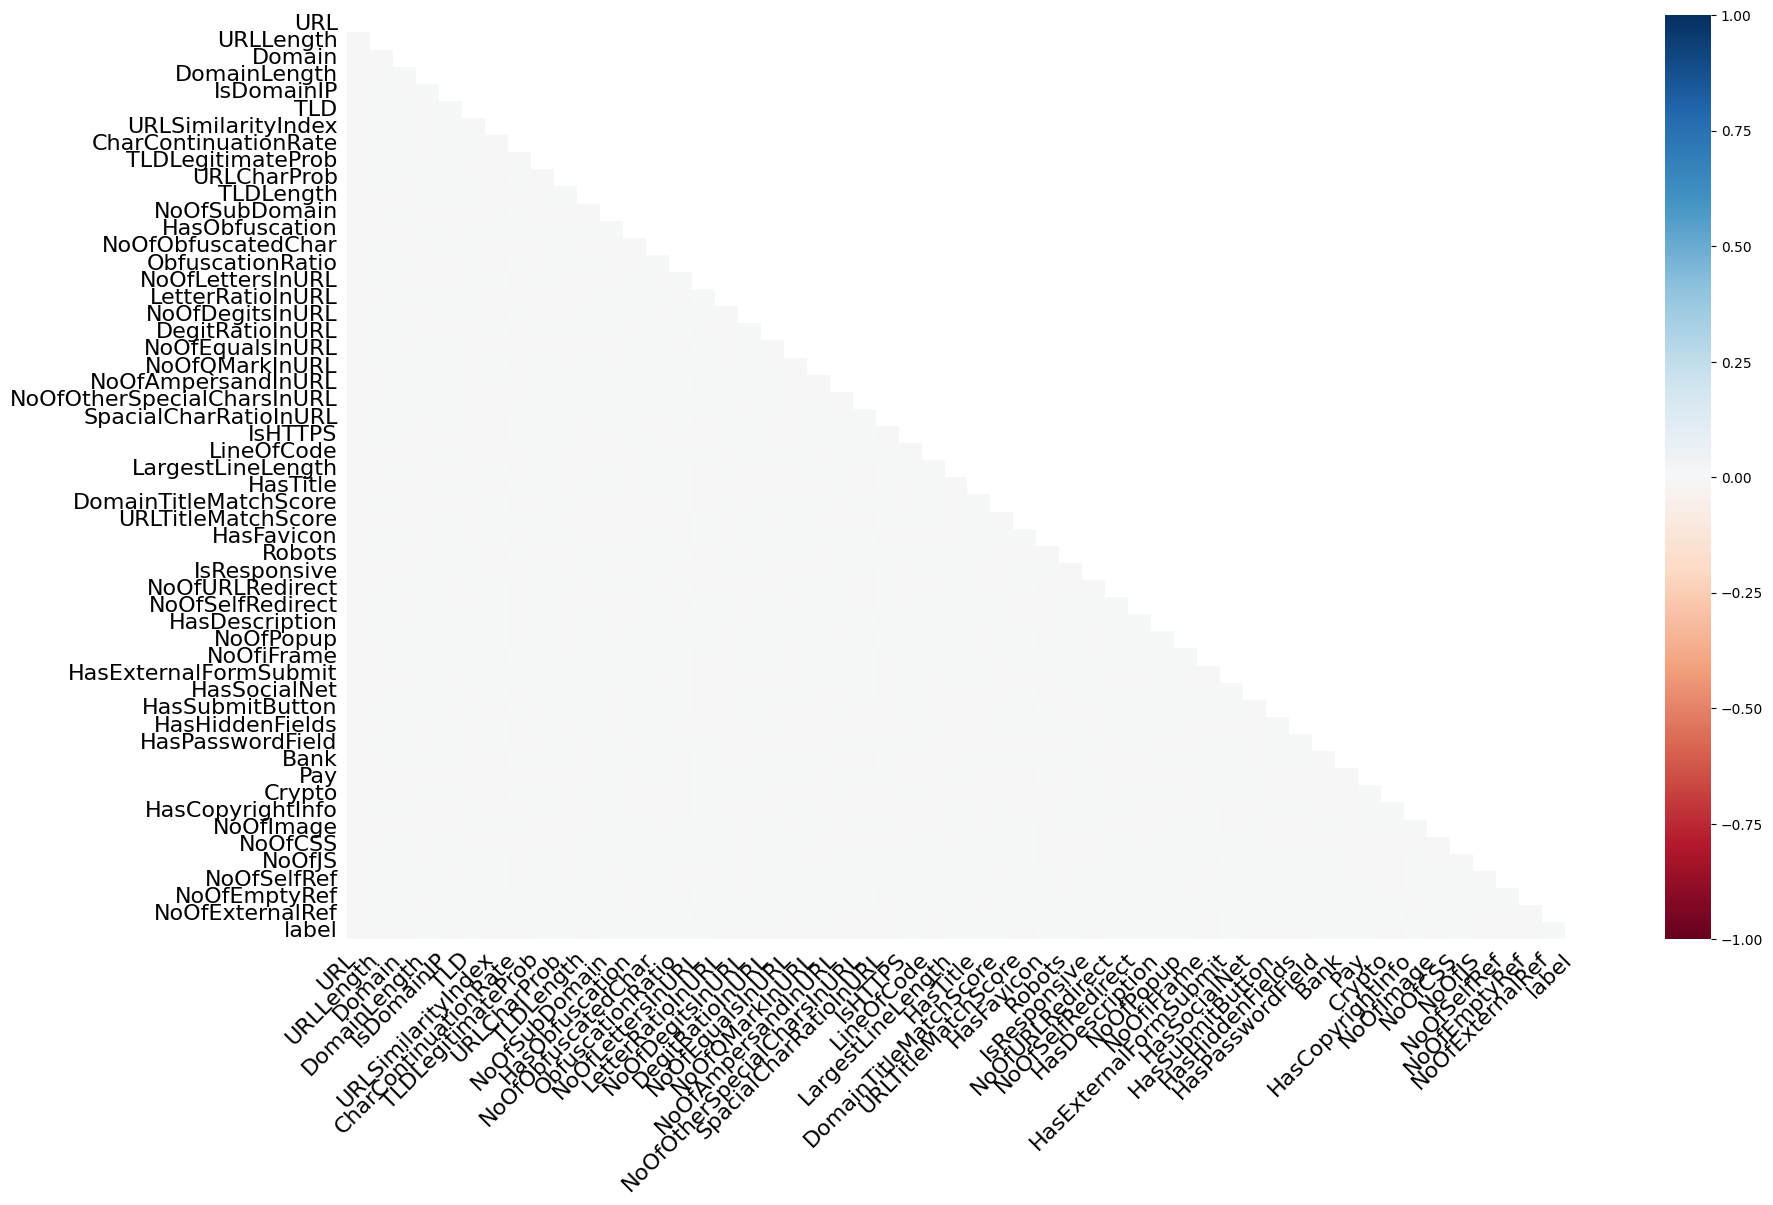

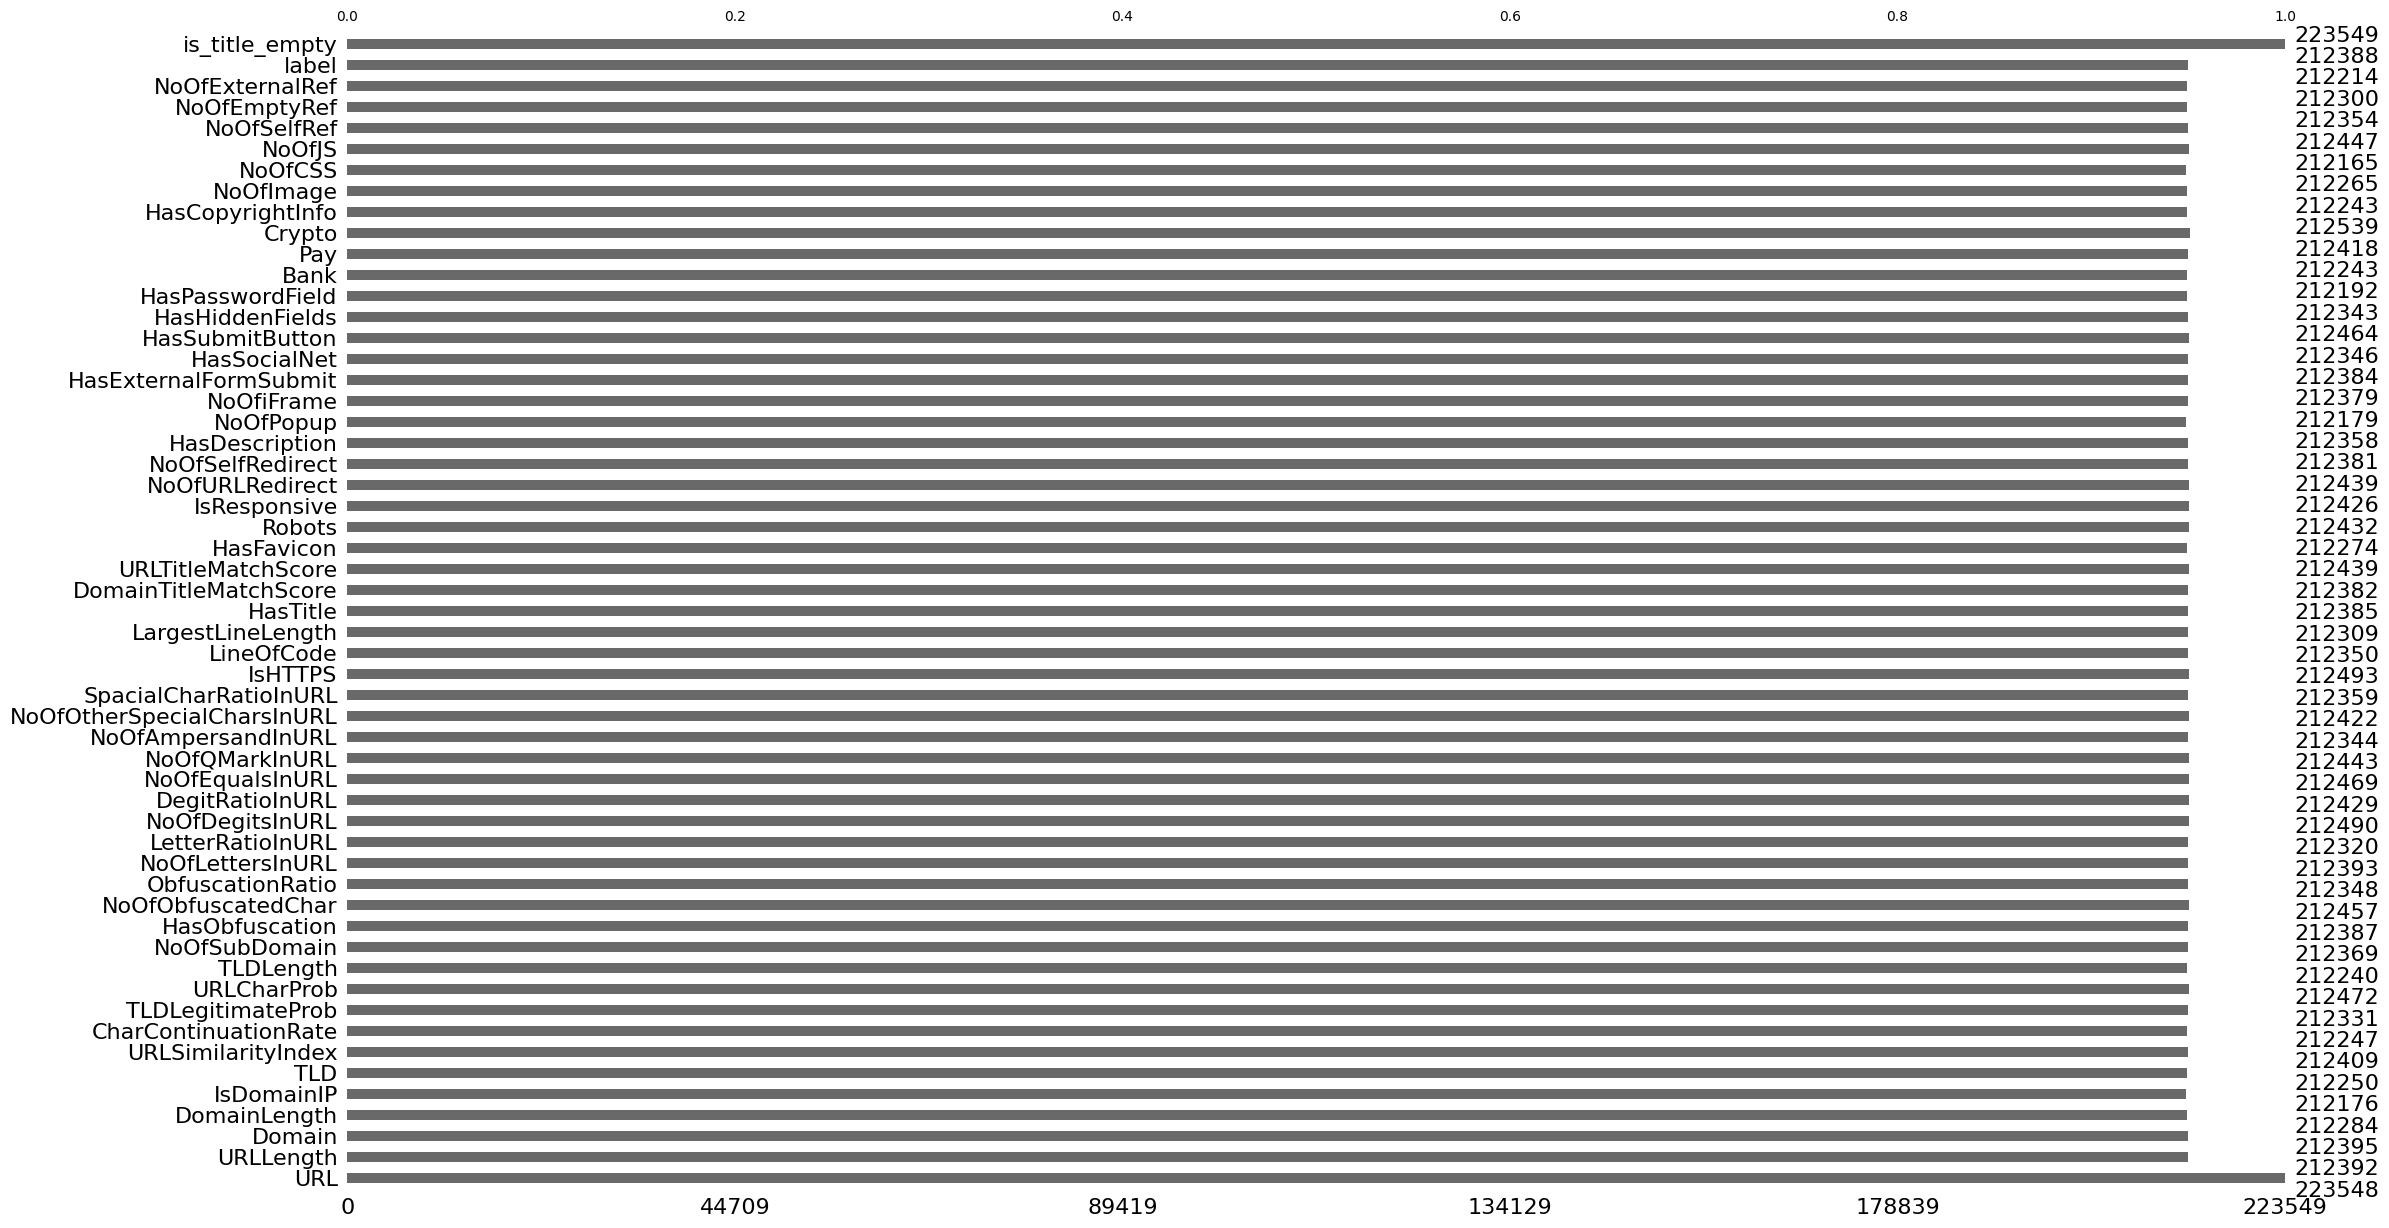

In [166]:
# I find that people use missingno library for visualizing missing data
import missingno as msno
import matplotlib.pyplot as plt
msno.matrix(df_raw)
plt.show()
msno.heatmap(df_raw)
plt.show()
msno.bar(df_raw)
plt.show()
# conclusion: The Missing Value Analysis confirms that the data are MCAR.

#bunu EDA ekle: # 2. DROP SPECIFIC COLUMNS
# Removing the "cheat" feature (URLSimilarityIndex) and the probability feature
#there are categorical columns with high cardinality, so I will drop them bc they may not contribute much to the model performance
#also TLD and TLDLegitimateProb are correlated, so dropping TLDLegitimateProb and delete URLSimilarityIndex to avoid model just relying on URL similarityindex to cheat
# errors='ignore' ensures code doesn't crash if columns are already gone

##############
DATA SPLIT VE TLDLEGITPROB, URLsimlaryindex'in drop edilmis imalancea dikkat edilerek

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer  # Required for MICE
from sklearn.impute import IterativeImputer
from category_encoders import TargetEncoder

# 1. DROP ROWS WITH MISSING LABELS
# We cannot use rows without a target for training or testing
df = df_raw.dropna(subset=['label'])

# 2. DROP SPECIFIC COLUMNS
# Removing the "cheat" feature (URLSimilarityIndex) and the probability feature
#there are categorical columns with high cardinality, so I will drop them bc they may not contribute much to the model performance
#also TLD and TLDLegitimateProb are correlated, so dropping TLDLegitimateProb and delete URLSimilarityIndex to avoid model just relying on URL similarityindex to cheat
# errors='ignore' ensures code doesn't crash if columns are already gone

# 3. STRATIFIED TRAIN-TEST SPLIT (70% Train, 30% Test)
X = df.drop(columns=['label'])
y = df['label']
set.seed(16)
# stratify=y ensures the ratio of Phishing/Legit is the same in Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y 
)
#for EDA purpose I will save X_train combine with y_train as Phishing_URL_ds_5percent_missing_train.csv
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined.to_csv('Phishing_URL_ds_5percent_missing_train.csv', index=False)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")



Train Shape: (148671, 54), Test Shape: (63717, 54)


TARGET ENCODING

In [168]:
# 4. TARGET ENCODING (TLD)
tld_col = 'TLD'

if tld_col in X_train.columns:
    # We use smoothing to prevent overfitting on rare TLDs
    encoder = TargetEncoder(cols=[tld_col], smoothing=10)
    
    # CRITICAL: Fit ONLY on X_train to prevent data leakage
    X_train[tld_col] = encoder.fit_transform(X_train[tld_col], y_train)
    
    # Transform X_test using the rules learned from X_train
    X_test[tld_col] = encoder.transform(X_test[tld_col])
    print("Target Encoding applied successfully.")
#drop unneccersary columns after encoding to apply MICE
cols_to_drop = ['TLDLegitimateProb', 'URLSimilarityIndex','FILENAME', 'URL', 'Domain', 'Title']
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

# 5. MICE IMPUTATION
# Initializes the MICE imputer
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# CRITICAL: Fit ONLY on X_train
# MICE learns the relationships between columns in the training set
X_train_matrix = mice_imputer.fit_transform(X_train)

# Apply those relationships to fill gaps in X_test
X_test_matrix = mice_imputer.transform(X_test)

# Convert back to DataFrame (because Imputer returns Numpy Arrays)
X_train = pd.DataFrame(X_train_matrix, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_matrix, columns=X_test.columns, index=X_test.index)

print("Preprocessing complete. X_train and X_test are ready for modeling.")

Target Encoding applied successfully.
Preprocessing complete. X_train and X_test are ready for modeling.


In [169]:
Train = pd.concat([X_train, y_train], axis=1)
Test = pd.concat([X_test, y_test], axis=1)

In [170]:
print(f"After the cleaning size of our df: {Train.shape}")
print(f"Total NaN number: {Train.isnull().sum().sum()}")
print(f"After the cleaning size of our df: {Test.shape}")
print(f"Total NaN number: {Test.isnull().sum().sum()}")

After the cleaning size of our df: (148671, 51)
Total NaN number: 0
After the cleaning size of our df: (63717, 51)
Total NaN number: 0


In [171]:
#fixing binary columns scaling issue bc MICE may have changed binary columns to non-binary
binary_cols = [
    'IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 
    'Robots', 'IsResponsive', 'HasDescription', 'HasExternalFormSubmit', 
    'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 
    'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo','is_title_empty'
    ]
for col in binary_cols:
    if col in Train.columns:
        # SENİN İSTEDİĞİN GARANTİ YÖNTEM (Vectorized Thresholding)
        # Değer 0.5'ten büyükse True(1) olur, değilse False(0) olur.
        # .astype(int) ile True/False'u 1/0'a çeviririz.
        Train[col] = (Train[col] > 0.5).astype(int)
for col in binary_cols:
    if col in Test.columns:
        # SENİN İSTEDİĞİN GARANTİ YÖNTEM (Vectorized Thresholding)
        # Değer 0.5'ten büyükse True(1) olur, değilse False(0) olur.
        # .astype(int) ile True/False'u 1/0'a çeviririz.
        Test[col] = (Test[col] > 0.5).astype(int)

In [172]:
print(Train[binary_cols].nunique())
print(Test[binary_cols].describe())

IsDomainIP               2
HasObfuscation           2
IsHTTPS                  2
HasTitle                 2
HasFavicon               2
Robots                   2
IsResponsive             2
HasDescription           2
HasExternalFormSubmit    2
HasSocialNet             2
HasSubmitButton          2
HasHiddenFields          2
HasPasswordField         2
Bank                     2
Pay                      2
Crypto                   2
HasCopyrightInfo         2
is_title_empty           2
dtype: int64
         IsDomainIP  HasObfuscation       IsHTTPS      HasTitle    HasFavicon  \
count  63717.000000    63717.000000  63717.000000  63717.000000  63717.000000   
mean       0.002542        0.001930      0.785332      0.860194      0.365224   
std        0.050359        0.043894      0.410595      0.346788      0.481497   
min        0.000000        0.000000      0.000000      0.000000      0.000000   
25%        0.000000        0.000000      1.000000      1.000000      0.000000   
50%        0.00

In [ ]:
Train.to_csv('Phishing_URL_ds_imputed_train.csv', index=False)
Test.to_csv('Phishing_URL_ds_imputed_test.csv', index=False)